In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
import IPython.display as display

# Define Project Root (Assuming notebook is in notebooks/)
PROJECT_ROOT = Path.cwd().parent
print(f"Project Root: {PROJECT_ROOT}")

Project Root: /home/jatin/projects/deeplearning/image_classification


In [23]:
# Configuration (Edit this cell)
MODEL_REL_PATH = "outputs/custom_cnn_v1/best_model.keras"  # Path relative to project root
IMAGE_REL_PATH = "data/OBJ_787/058.jpeg"  # Update with a real image path
MANIFEST_REL_PATH = "split_manifest.json"
CONFIDENCE_THRESHOLD = 0.9
IMG_SIZE = (224, 224)

In [24]:
# Load Class Names
manifest_path = PROJECT_ROOT / MANIFEST_REL_PATH

if not manifest_path.exists():
    raise FileNotFoundError(f"Manifest not found at {manifest_path}")

with open(manifest_path, 'r') as f:
    manifest = json.load(f)

class_to_idx = manifest.get('class_to_idx', {})
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Loaded {num_classes} classes from manifest.")

Loaded 39 classes from manifest.


In [25]:
# Load Model
model_path = PROJECT_ROOT / MODEL_REL_PATH

if not model_path.exists():
    raise FileNotFoundError(f"Model not found at {model_path}")

print(f"Loading model from {model_path}...")
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")
model.summary()

Loading model from /home/jatin/projects/deeplearning/image_classification/outputs/custom_cnn_v1/best_model.keras...
Model loaded successfully.


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,396,535 (5.33 MB)

 Trainable params: 465,191 (1.77 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 930,384 (3.55 MB)

In [26]:
# Load and Preprocess Image
image_path = PROJECT_ROOT / IMAGE_REL_PATH

if not image_path.exists():
    # Try to find a valid image if the default one doesn't exist
    print(f"Image not found at {image_path}. Trying to find a random image from data/...")
    data_dir = PROJECT_ROOT / "data"
    possible_images = list(data_dir.glob("**/*.jpg")) + list(data_dir.glob("**/*.png"))
    if possible_images:
        image_path = possible_images[0]
        print(f"Using found image: {image_path}")
    else:
        raise FileNotFoundError(f"No images found in {data_dir}")

def preprocess_image(path, target_size):
    image_content = tf.io.read_file(str(path))
    # decode_image handles both png and jpg
    image = tf.image.decode_image(image_content, channels=3, expand_animations=False)
    image = tf.image.resize(image, target_size)
    # Cast to float32 (keep 0-255 range)
    image = tf.cast(image, tf.float32)
    return image

original_image_tensor = preprocess_image(image_path, IMG_SIZE)
# Add batch dimension
input_tensor = tf.expand_dims(original_image_tensor, 0)

# Convert to uint8 for display
display_image = tf.cast(original_image_tensor, tf.uint8).numpy()

print(f"Processed image shape: {input_tensor.shape}")

Processed image shape: (1, 224, 224, 3)


Running inference...


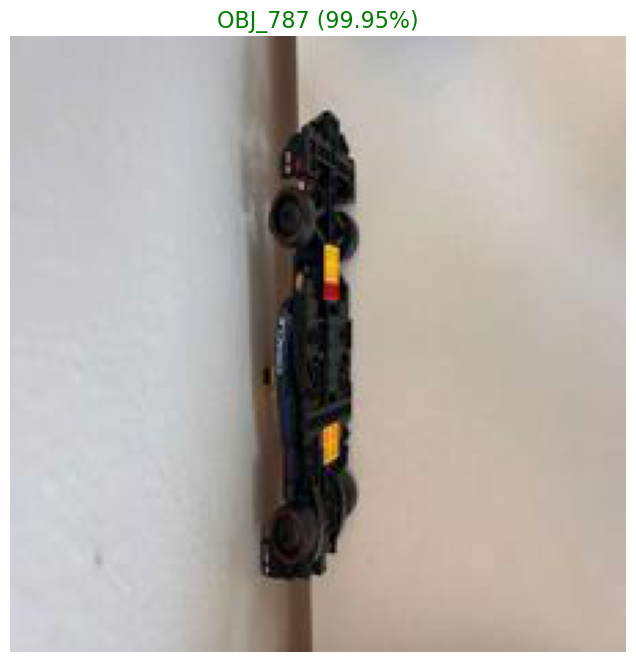

In [27]:
# Run Inference
print("Running inference...")
predictions = model.predict(input_tensor, verbose=0)
predicted_idx = np.argmax(predictions[0])
confidence = predictions[0][predicted_idx]
predicted_class = idx_to_class.get(predicted_idx, "Unknown")

# Display Result
plt.figure(figsize=(8, 8))
plt.imshow(display_image)
plt.axis('off')

if confidence >= CONFIDENCE_THRESHOLD:
    title_text = f"{predicted_class} ({confidence:.2%})"
    title_color = 'green'
else:
    title_text = f"UNCERTAIN - {predicted_class} ({confidence:.2%})"
    title_color = 'red'

plt.title(title_text, color=title_color, fontsize=16)
plt.show()

In [28]:
# Top-5 Predictions
top_5_indices = np.argsort(predictions[0])[-5:][::-1]

print(f"{'Rank':<5} | {'Class':<20} | {'Confidence'}")
print("-" * 40)
for i, idx in enumerate(top_5_indices):
    class_name = idx_to_class.get(idx, "Unknown")
    conf = predictions[0][idx]
    print(f"{i+1:<5} | {class_name:<20} | {conf:.2%}")

Rank  | Class                | Confidence
----------------------------------------
1     | OBJ_787              | 99.95%
2     | OBJ_016              | 0.05%
3     | OBJ_003              | 0.00%
4     | OBJ_311              | 0.00%
5     | OBJ_229              | 0.00%
